# 05b. Gaussian Naive Bayes Baseline - Automobile Loan Default Prediction


## 1. Setup


In [1]:
import os
import sys

project_root = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
from src.config import RANDOM_STATE, TARGET
from src.data.data_cleaning import clean_and_split
from src.evaluation.metrics import evaluate_model

train_df, test_df = clean_and_split()
X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Default rate (train):", round(y_train.mean(), 4))
print("Default rate (test):", round(y_test.mean(), 4))


X_train shape: (85756, 40)
X_test shape: (21440, 40)
Default rate (train): 0.0809
Default rate (test): 0.0809


## 2. Gaussian Naive Bayes

Fast probabilistic baseline. Correct NB variant for our data - it assumes real-valued, normally-distributed features per class, which fits our standard-scaled continuous features (unlike Multinomial NB, which needs non-negative counts). Expected to underperform the ensembles: it assumes features are independent given the class, which breaks for correlated features like `score_mean` vs. `Score_Source_1/2/3`, or `credit_to_income` vs. `Credit_Amount`.


In [3]:
from src.models.gaussian_naive_bayes import build_gaussian_naive_bayes_pipeline

nb_pipeline = build_gaussian_naive_bayes_pipeline()

nb_results = evaluate_model(nb_pipeline, X_train, y_train, model_name="gaussian_naive_bayes", cv=5)

for key, value in nb_results.items():
    print(f"{key}: {value}")


model_name: gaussian_naive_bayes
cv_folds: 5
threshold: 0.5
roc_auc_mean: 0.6966276721425656
roc_auc_std: 0.003053218082188142
pr_auc_mean: 0.18133986089730006
pr_auc_std: 0.005621102809360923
recall_mean: 0.4921450549085756
precision_mean: 0.17121530278047517
f1_mean: 0.2540279792035506
confusion_matrix: [[62283, 16532], [3525, 3416]]
fit_seconds: 14.94


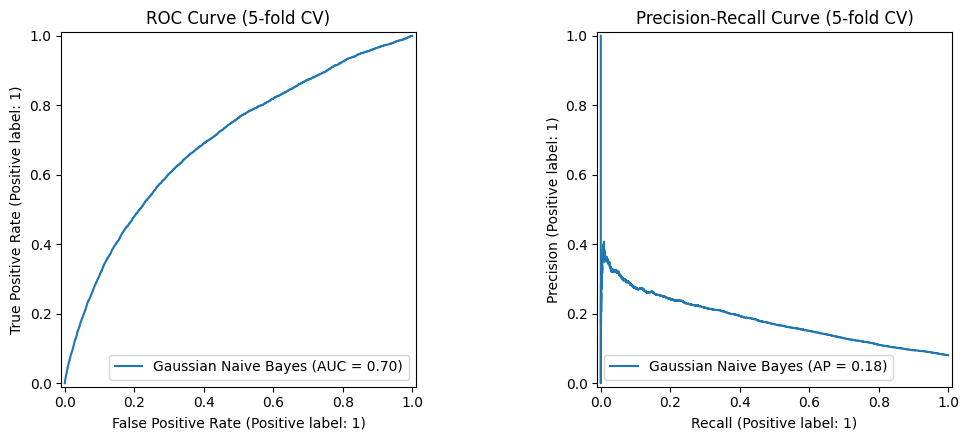

In [4]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_predict

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
figures_dir = "experiments/figures" if os.path.exists("experiments/figures") else "../experiments/figures"

nb_cv_proba = cross_val_predict(nb_pipeline, X_train, y_train, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
RocCurveDisplay.from_predictions(y_train, nb_cv_proba, ax=axes[0], name="Gaussian Naive Bayes")
axes[0].set_title("ROC Curve (5-fold CV)")
PrecisionRecallDisplay.from_predictions(y_train, nb_cv_proba, ax=axes[1], name="Gaussian Naive Bayes")
axes[1].set_title("Precision-Recall Curve (5-fold CV)")
plt.tight_layout()

plt.savefig(os.path.join(figures_dir, "05_gaussian_nb_roc_pr.png"), dpi=100, bbox_inches="tight")
plt.show()


In [5]:
from src.evaluation.metrics import log_result_to_csv

results_dir = "experiments/results" if os.path.exists("experiments/results") else "../experiments/results"
experiments_path = os.path.join(results_dir, "experiments.csv")

log_result_to_csv(nb_results, experiments_path)
print(f"Logged to {experiments_path}")
pd.read_csv(experiments_path)


Logged to ../experiments/results\experiments.csv


,model_name,cv_folds,threshold,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,recall_mean,precision_mean,f1_mean,fit_seconds,tn,fp,fn,tp
0,XGBoost Baseline,5,0.5,0.763093,0.004383,0.261403,0.009897,0.022009,0.621743,0.042488,39.12,87542,106,7554,170
1,XGBoost Baseline,5,0.5,0.763093,0.004383,0.261403,0.009897,0.022009,0.621743,0.042488,20.98,87542,106,7554,170
2,XGBoost Baseline,5,0.5,0.737738,0.004882,0.220956,0.004845,0.556546,0.186343,0.279202,51.90,61945,16870,3078,3863
3,random_forest,5,0.5,0.730168,0.003138,0.209117,0.005225,0.065841,0.365528,0.111532,67.88,78021,794,6484,457
4,random_forest_tuned,5,0.5,0.735709,0.004099,0.214796,0.005722,0.488834,0.198028,0.281869,64.90,65075,13740,3548,3393
5,LightGBM Baseline,5,0.5,0.741617,0.003304,0.217958,0.004805,0.637661,0.168685,0.266791,36.54,57000,21815,2515,4426
6,decision_tree,5,0.5,0.707924,0.005046,0.178402,0.002034,0.646017,0.145725,0.237679,14.62,52490,26325,2457,4484
7,gaussian_naive_bayes,5,0.5,0.696628,0.003053,0.181340,0.005621,0.492145,0.171215,0.254028,14.94,62283,16532,3525,3416


**Finding:** Gaussian Naive Bayes 5-fold CV on the cleaned training split (near-duplicate applicants removed, 85,756 rows) - ROC-AUC 0.697 +/- 0.003, PR-AUC 0.181 +/- 0.006. It is the weakest model, below untuned Random Forest (0.730 / 0.209) and every other model, as expected from its assumption that features are independent given the class: the score and ratio features are strongly correlated. At the default 0.5 threshold its recall is higher than untuned Random Forest's (0.492 vs. 0.066), at the cost of lower precision (0.171 vs. 0.366); thresholds are compared properly in 06b.

**Decision:** kept as the simple probabilistic baseline in `src/models/gaussian_naive_bayes.py` (`build_gaussian_naive_bayes_pipeline()`); not tuned, since it has one parameter and is clearly the weakest model.
